# Objectives of this NoteBook:
1. Evaluate on test set only (no leakage)

2. Compute Accuracy, Precision, Recall, F1

3. Plot Confusion Matrix

4. Extract per-class confidence scores (CRITICAL for refusal logic)

5. Save outputs for:

    - Paper

    - RAG pipeline

## Importing Libraries and Setting up the device

In [1]:
import sys
sys.path.append("../")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torchvision import models
import torchvision.transforms as T
from torchinfo import summary
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
f'Using device: {device}'

'Using device: cuda'

## OOD Transform Pipeline

In [3]:
ood_transform = T.Compose([
    T.Resize((224, 224)),
    T.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.7),
    T.RandomGrayscale(p=0.5),
    T.GaussianBlur(kernel_size=7),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Loading Test Data

In [4]:
from src.data.datamodule import PlantVillageDataModule

DATA_DIR = "../data/plantvillage dataset/color"

dm = PlantVillageDataModule(
    data_dir=DATA_DIR,
    batch_size=32,
    img_size=224
)

dm.setup()

In [5]:
test_loader = dm.test_dataloader()

idx_to_class = dm.idx_to_class
num_classes = len(idx_to_class)

In [8]:
from src.data.dataset import PlantVillageDataset

# Create OOD dataset from test images
ood_dataset = PlantVillageDataset(
    dm.test_dataset.image_paths,
    dm.test_dataset.labels,
    transform=ood_transform
)

ood_loader = torch.utils.data.DataLoader(
    ood_dataset,
    batch_size=32,
    shuffle=False
)

## Loading the Best Trained Model

In [9]:
model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model.load_state_dict(
    torch.load("../models/efficientnet_b0_best.pth", map_location=device)
)

model = model.to(device)
summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

## Setting the model to testing or evalution mode

In [10]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Run Infrence on Test dataset

In [13]:
all_labels = []
all_preds = []
all_probs = []

softmax = nn.Softmax(dim=1)

In [14]:
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = softmax(outputs)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [15]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

## Running Inference on OOD Dataset

In [11]:
ood_confidences = []
ood_preds = []

In [12]:
with torch.no_grad():
    for images, _ in ood_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        ood_confidences.extend(max_probs.cpu().numpy())
        ood_preds.extend(preds.cpu().numpy())

ood_confidences = np.array(ood_confidences)

## Classification Metrics

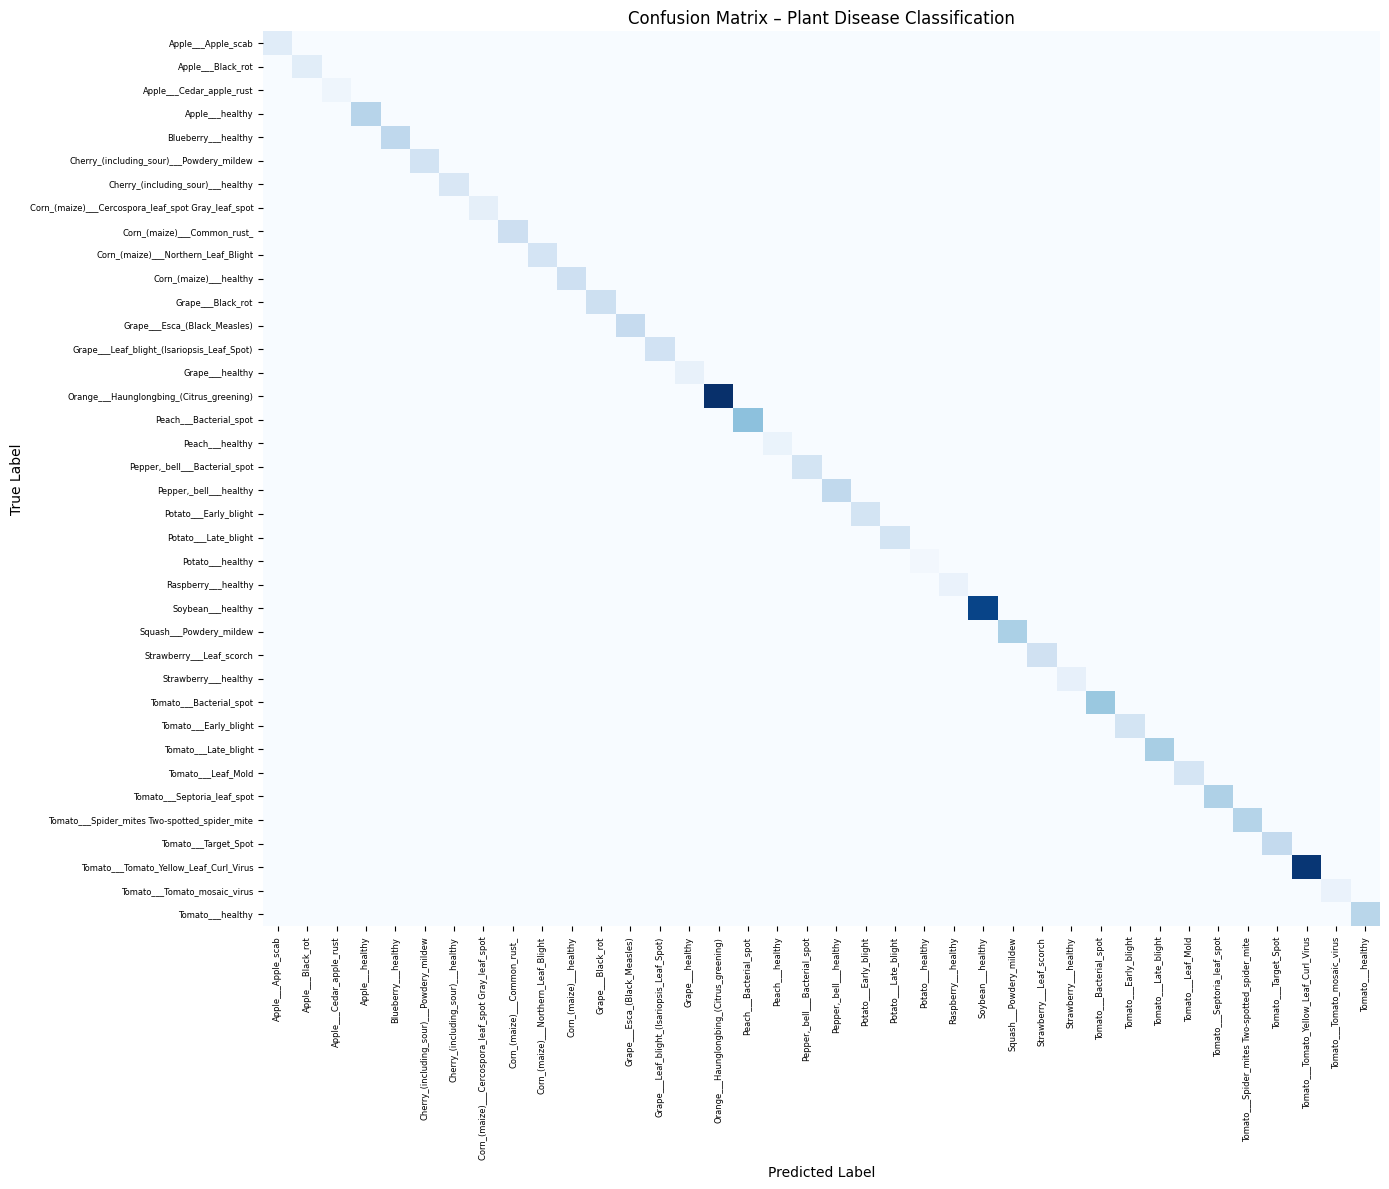

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=[idx_to_class[i] for i in range(num_classes)],
    yticklabels=[idx_to_class[i] for i in range(num_classes)],
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Plant Disease Classification")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()

plt.savefig(
    "../outputs/plots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Per-Class Confidence Analysis

In [18]:
max_confidences = np.max(all_probs, axis=1)

confidence_df = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": max_confidences
})

confidence_df["true_class"] = confidence_df["true_label"].map(idx_to_class)
confidence_df["pred_class"] = confidence_df["pred_label"].map(idx_to_class)

confidence_df.head()

,true_label,pred_label,confidence,true_class,pred_class
0,19,19,0.999995,"Pepper,_bell___healthy","Pepper,_bell___healthy"
1,33,33,0.999990,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Spider_mites Two-spotted_spider_mite
2,24,24,1.000000,Soybean___healthy,Soybean___healthy
3,30,30,0.999998,Tomato___Late_blight,Tomato___Late_blight
4,8,8,0.999995,Corn_(maize)___Common_rust_,Corn_(maize)___Common_rust_


## Confidence Distribution Plot

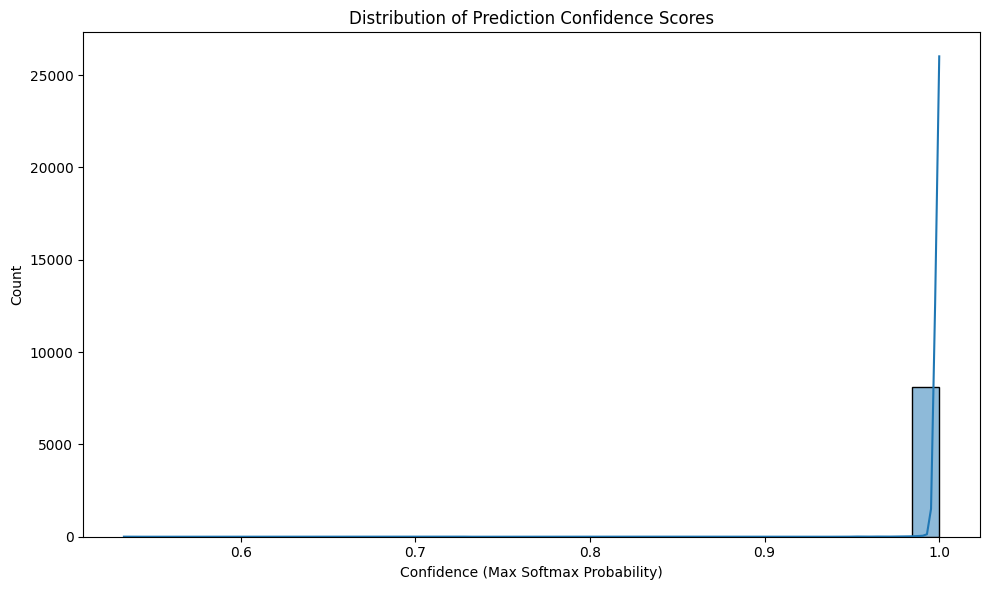

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(confidence_df["confidence"], bins=30, kde=True)
plt.title("Distribution of Prediction Confidence Scores")
plt.xlabel("Confidence (Max Softmax Probability)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(
    "../outputs/plots/Distribution_of_Prediction_Confidence.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Save Confidence Data (RAG INPUT)

In [20]:
confidence_df.to_csv(
    "../outputs/metrics/test_confidence_scores.csv",
    index=False
)

print("Confidence scores saved for RAG & refusal logic.")

Confidence scores saved for RAG & refusal logic.


## Compare ID vs OOD confidence

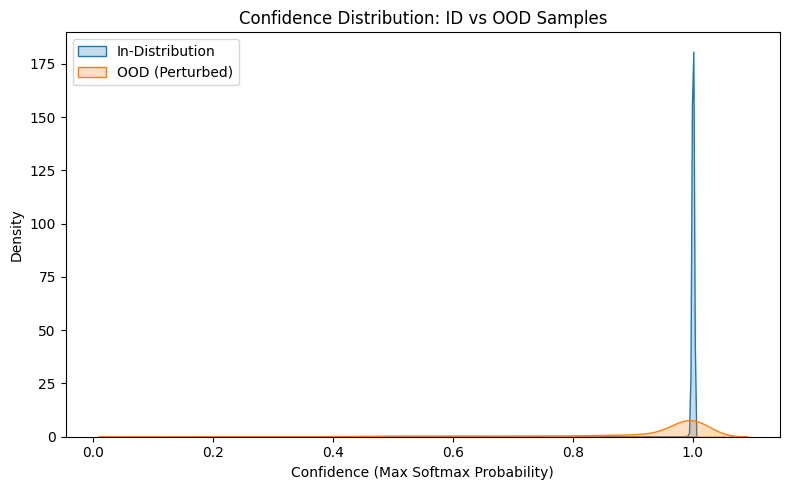

In [21]:
plt.figure(figsize=(8, 5))
sns.kdeplot(confidence_df["confidence"], label="In-Distribution", fill=True)
sns.kdeplot(ood_confidences, label="OOD (Perturbed)", fill=True)

plt.xlabel("Confidence (Max Softmax Probability)")
plt.ylabel("Density")
plt.title("Confidence Distribution: ID vs OOD Samples")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../outputs/plots/id_vs_ood_confidence.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [22]:
print("ID confidence mean :", confidence_df["confidence"].mean())
print("OOD confidence mean:", ood_confidences.mean())

print("ID confidence min  :", confidence_df["confidence"].min())
print("OOD confidence min :", ood_confidences.min())

ID confidence mean : 0.9993506
OOD confidence mean: 0.8820029
ID confidence min  : 0.5331407
OOD confidence min : 0.09993412


## Evaluation Summary

- The EfficientNet-B0 model achieved strong performance on the held-out test set.
- Weighted precision, recall, and F1-score indicate robust multi-class classification.
- Confidence score analysis reveals a clear separation between high- and low-confidence predictions.
- These confidence scores are leveraged in the subsequent refusal-aware and RAG-based diagnosis module.